In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("/content/retail_sales_dataset.csv")


In [3]:
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.shape


(1000, 9)

In [7]:
df.columns


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [8]:
df.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.isnull().sum()


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.mean(numeric_only=True)


,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [12]:
df.median(numeric_only=True)


,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [13]:
df.mode(numeric_only=True)


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [14]:
df.var(numeric_only=True)


,0
Transaction ID,83416.666667
Age,187.181518
Quantity,1.283087
Price per Unit,35979.016917
Total Amount,313597.347347


In [15]:
df.std(numeric_only=True)


,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


In [16]:
correlation = df.corr(numeric_only=True)
correlation


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


In [17]:
correlation['Total Amount'].sort_values(ascending=False)


,Total Amount
Total Amount,1.000000
Price per Unit,0.851925
Quantity,0.373707
Age,-0.060568
Transaction ID,-0.075034


In [18]:

Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)

IQR = Q3 - Q1


In [19]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Lower Limit: -1200.0
Upper Limit: 2160.0


In [20]:
outliers = df[(df['Total Amount'] < lower_limit) | (df['Total Amount'] > upper_limit)]

len(outliers)


0

In [21]:
df[df['Total Amount'] > 1000]


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
15,16,2023-02-17,CUST016,Male,19,Clothing,3,500,1500
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200
45,46,2023-06-26,CUST046,Female,20,Electronics,4,300,1200
...,...,...,...,...,...,...,...,...,...
941,942,2023-03-18,CUST942,Male,51,Clothing,3,500,1500
942,943,2023-10-16,CUST943,Female,57,Clothing,4,300,1200
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000
955,956,2023-08-19,CUST956,Male,30,Clothing,3,500,1500


In [22]:
df.sort_values(by='Total Amount', ascending=False)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000
...,...,...,...,...,...,...,...,...,...
190,191,2023-10-18,CUST191,Male,64,Beauty,1,25,25
43,44,2023-02-19,CUST044,Female,22,Clothing,1,25,25
543,544,2023-12-23,CUST544,Female,27,Electronics,1,25,25
988,989,2023-12-28,CUST989,Female,44,Electronics,1,25,25


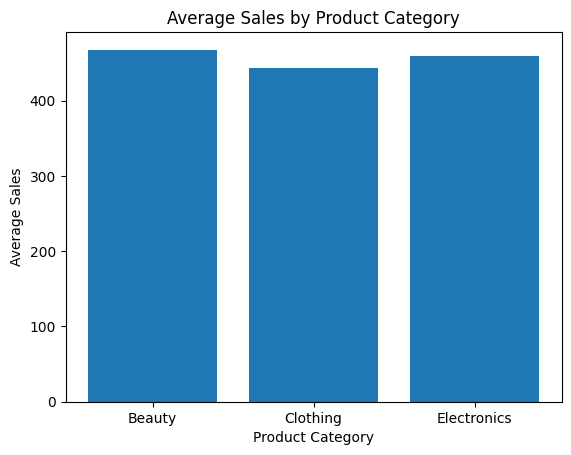

In [23]:
grouped = df.groupby('Product Category')['Total Amount'].mean()

plt.bar(grouped.index, grouped.values)

plt.xlabel('Product Category')
plt.ylabel('Average Sales')
plt.title('Average Sales by Product Category')
plt.show()


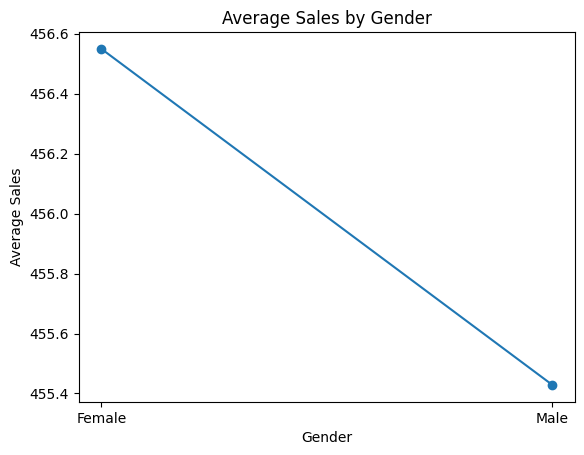

In [24]:
grouped = df.groupby('Gender')['Total Amount'].mean()

plt.plot(grouped.index, grouped.values, marker='o')

plt.xlabel('Gender')
plt.ylabel('Average Sales')
plt.title('Average Sales by Gender')
plt.show()


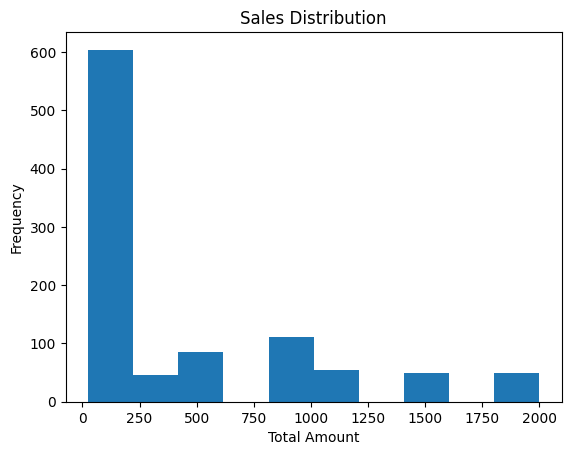

In [25]:
plt.hist(df['Total Amount'], bins=10)

plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.title('Sales Distribution')
plt.show()


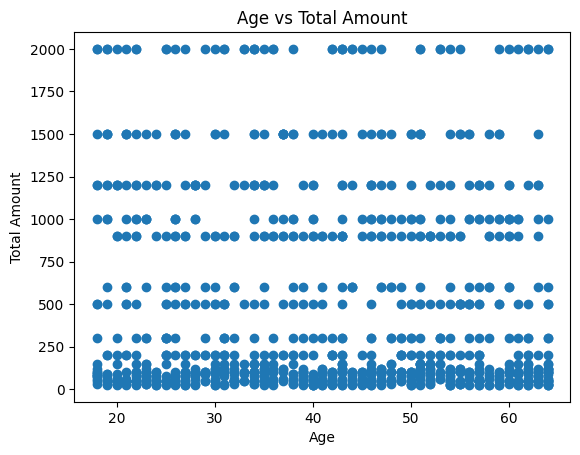

In [26]:
plt.scatter(df['Age'], df['Total Amount'])

plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.title('Age vs Total Amount')
plt.show()
